# Mango recalcitrant seed drying study (simulated, benchmarked from actual experimental studies, Petalcorin, M.I.R. (2026)

1) Generates simulated datasets for 4 treatments (ADWE, ADWO, SDWE, SDWO) across time.
2) Benchmarks parameter ranges using Journal-indexed papers on recalcitrant seed dehydration, electrolyte leakage, and respiration.
3) Runs extensive analysis (curve fitting, CMC estimation, time-to-failure, ANOVA-style models, correlation network, PCA).
4) Visualizes results (matplotlib figures).

## Benchmarks used 
- **Petalcorin, M.I.R.** (2026). Endocarp-modulated drying kinetics define a critical moisture threshold for bioenergetic failure, membrane destabilization, and metabolic collapse in recalcitrant mango seeds. GitHub. https://github.com/mpetalcorin/recalcitrant-seed-drying-simulator
- Mango seeds are highly hydrated at shedding and die rapidly on dehydration (Corbineau et al., 1986, PubMed: 14975891).  https://pubmed.ncbi.nlm.nih.gov/14975891
- Recalcitrant axes show drying-rate dependence and electrolyte leakage rises at relatively high water contents (Liang & Sun, 2000, PubMed: 11113169). https://pubmed.ncbi.nlm.nih.gov/11113169
- In desiccation-sensitive seeds, lethal damage relates to very high O2 consumption thresholds and critical water content; slow drying introduces ageing-type damage (Walters et al., 2001, Seed Sci Res).  https://www.cambridge.org/core/services/aop-cambridge-core/content/view/S0960258501000137
- Electrolyte leakage ranges and scaling with moisture loss in recalcitrant seeds (example: 0.035–0.081 mS g−1 DW baseline, rising with drying/storage) (Fuchs et al., 2023, PMC). https://pmc.ncbi.nlm.nih.gov/articles/PMC10335849
- Mango seed desiccation/storage study reports high MC (~69–75%) and strong increases in leachate conductivity with drying (Xiao-feng & Fu, abstract snippet). https://www.jipb.net/EN/abstract/abstract23528.shtml

## NOTE: Units for "conductivity" vary by protocol and reporting (µS cm−1 g−1 FW, mS g−1 DW, etc.).
## Here we standardize to "µS cm−1 g−1 (normalized)" as a pragmatic synthetic unit for modeling

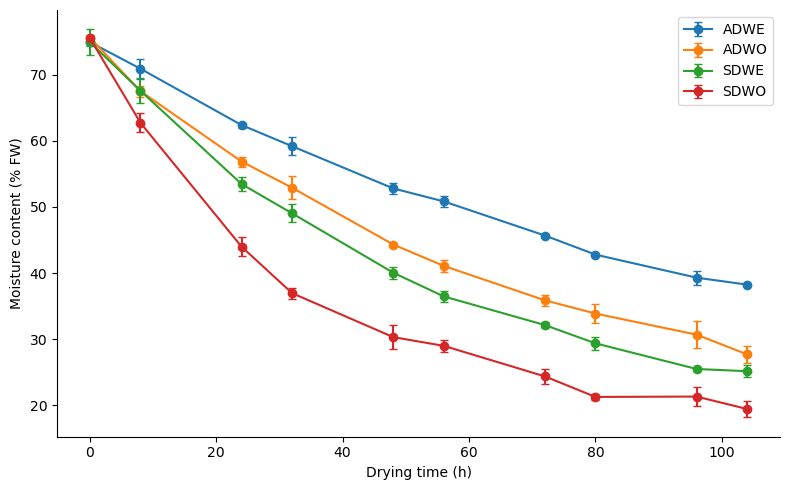

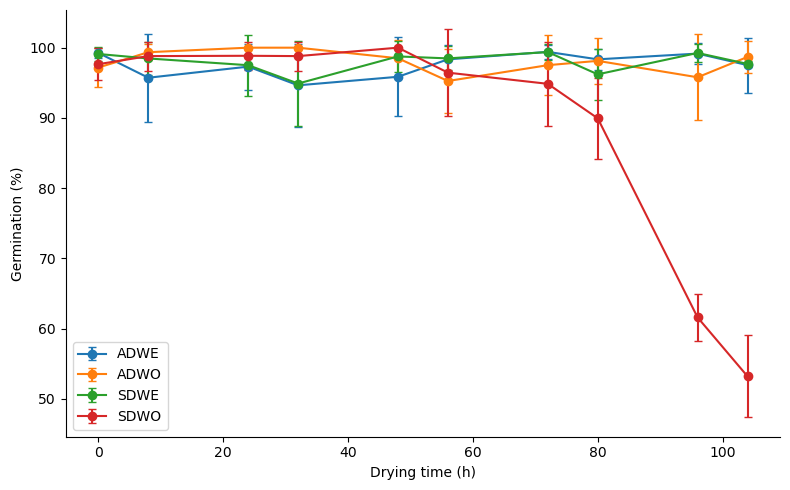

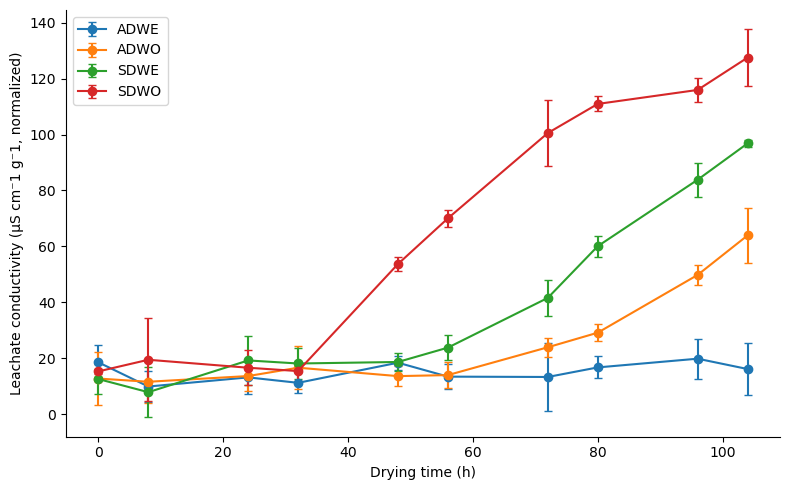

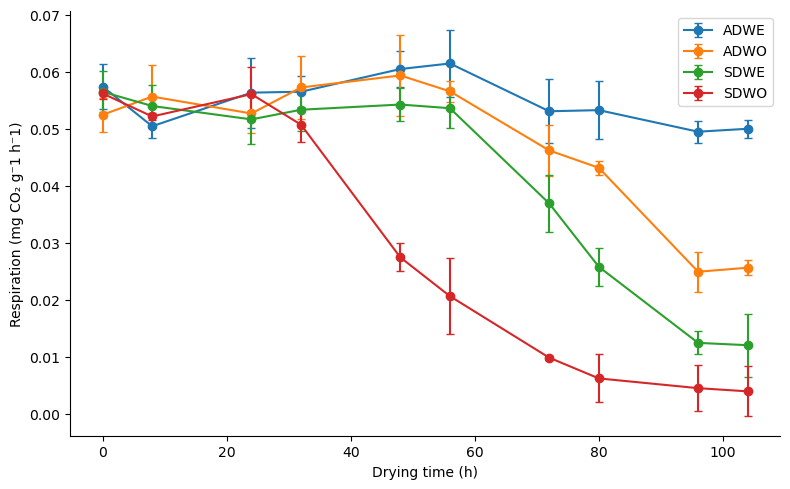

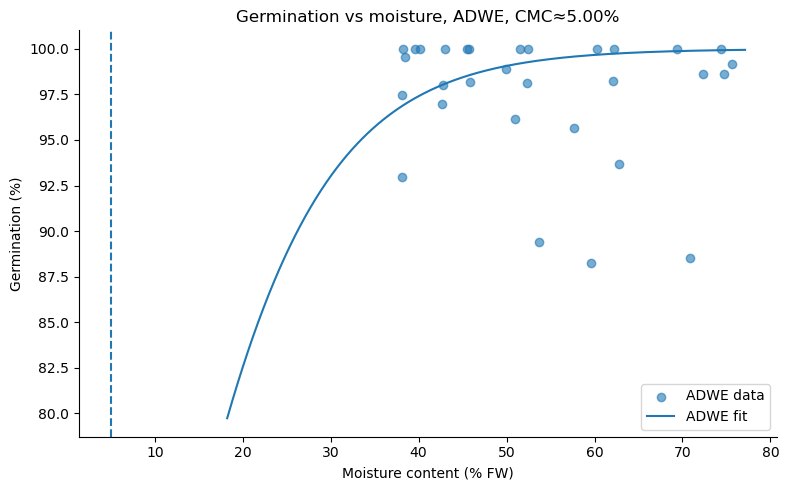

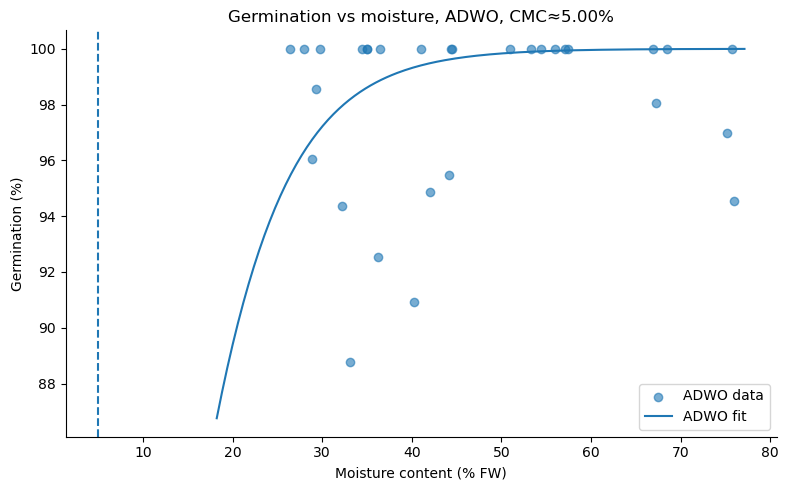

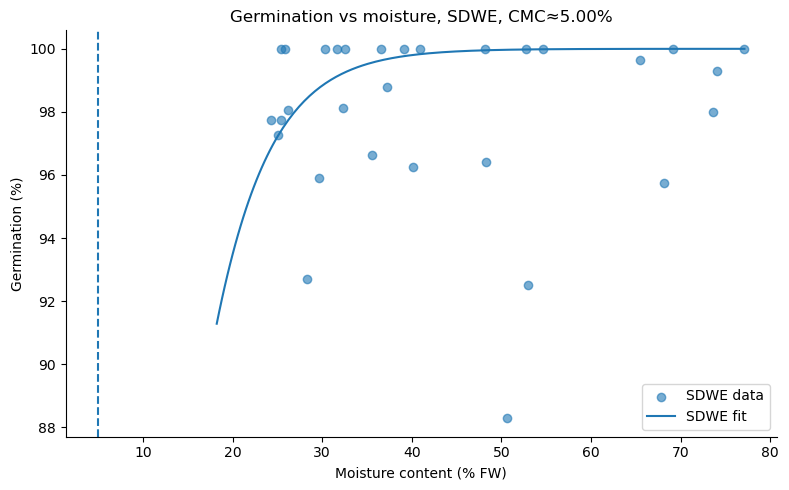

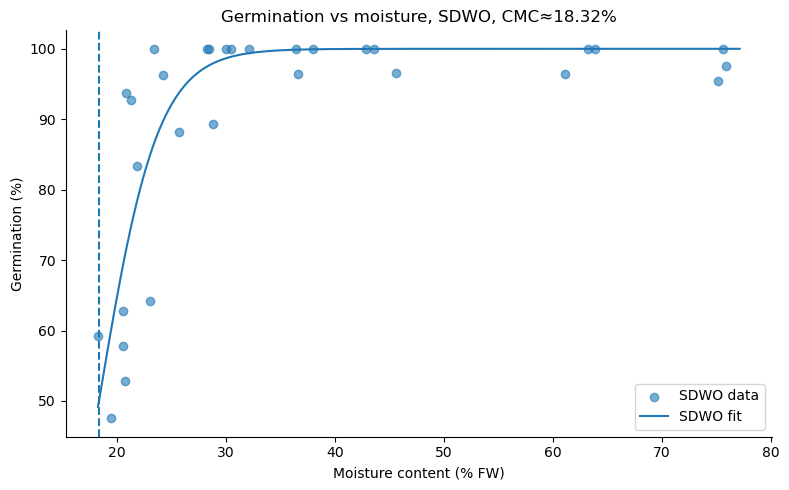

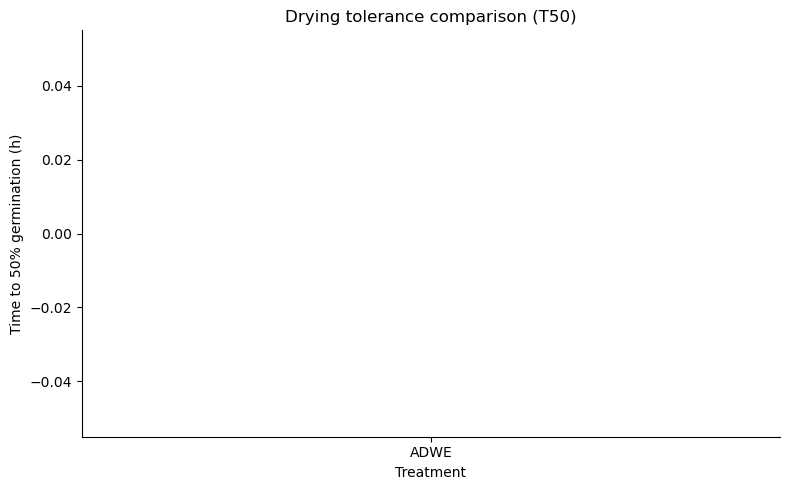


=== Spearman correlations: All data ===


,moisture_pct,conductivity_uS,respiration_mgCO2_g_h,germination_pct
moisture_pct,1.000,-0.791,0.768,0.209
conductivity_uS,-0.791,1.000,-0.747,-0.200
respiration_mgCO2_g_h,0.768,-0.747,1.000,0.238
germination_pct,0.209,-0.200,0.238,1.000



=== Spearman correlations: ADWE ===


,moisture_pct,conductivity_uS,respiration_mgCO2_g_h,germination_pct
moisture_pct,1.000,-0.196,0.324,-0.067
conductivity_uS,-0.196,1.000,0.087,-0.028
respiration_mgCO2_g_h,0.324,0.087,1.000,0.008
germination_pct,-0.067,-0.028,0.008,1.000



=== Spearman correlations: ADWO ===


,moisture_pct,conductivity_uS,respiration_mgCO2_g_h,germination_pct
moisture_pct,1.000,-0.796,0.671,0.124
conductivity_uS,-0.796,1.000,-0.785,-0.130
respiration_mgCO2_g_h,0.671,-0.785,1.000,0.194
germination_pct,0.124,-0.130,0.194,1.000



=== Spearman correlations: SDWE ===


,moisture_pct,conductivity_uS,respiration_mgCO2_g_h,germination_pct
moisture_pct,1.000,-0.916,0.837,0.071
conductivity_uS,-0.916,1.000,-0.860,-0.074
respiration_mgCO2_g_h,0.837,-0.860,1.000,-0.013
germination_pct,0.071,-0.074,-0.013,1.000



=== Spearman correlations: SDWO ===


,moisture_pct,conductivity_uS,respiration_mgCO2_g_h,germination_pct
moisture_pct,1.000,-0.921,0.946,0.676
conductivity_uS,-0.921,1.000,-0.911,-0.621
respiration_mgCO2_g_h,0.946,-0.911,1.000,0.680
germination_pct,0.676,-0.621,0.680,1.000


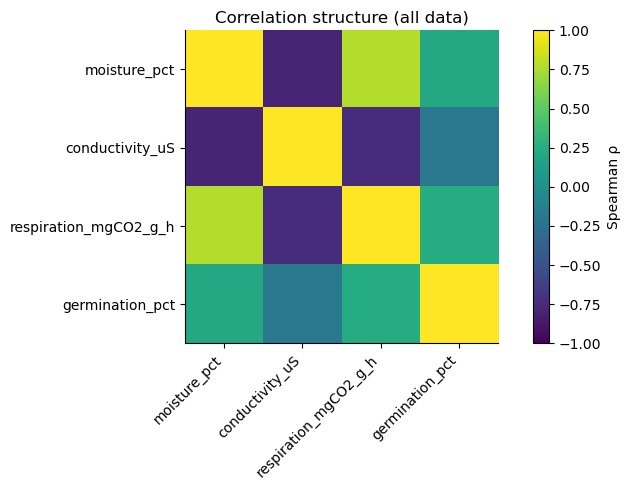

                            OLS Regression Results                            
Dep. Variable:        germination_pct   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     10.74
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           1.98e-07
Time:                        17:34:39   Log-Likelihood:                -421.24
No. Observations:                 120   AIC:                             852.5
Df Residuals:                     115   BIC:                             866.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

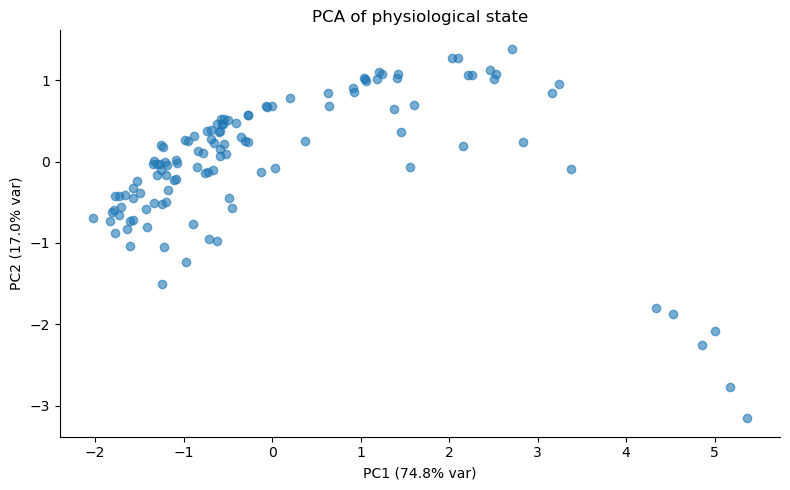

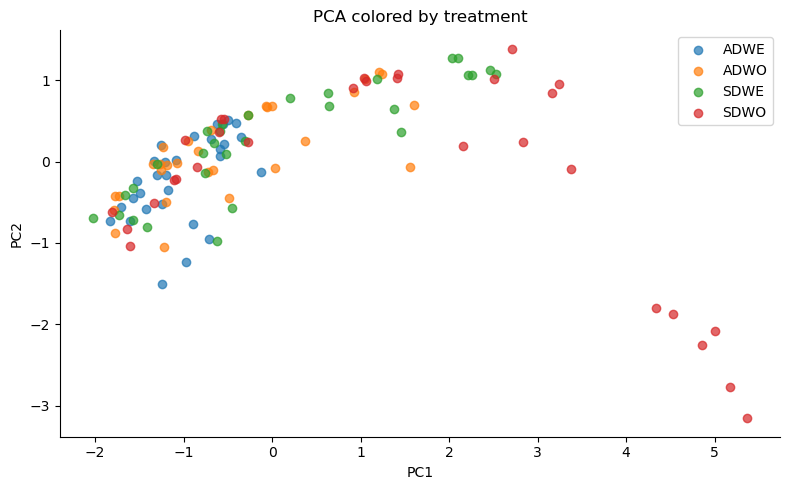

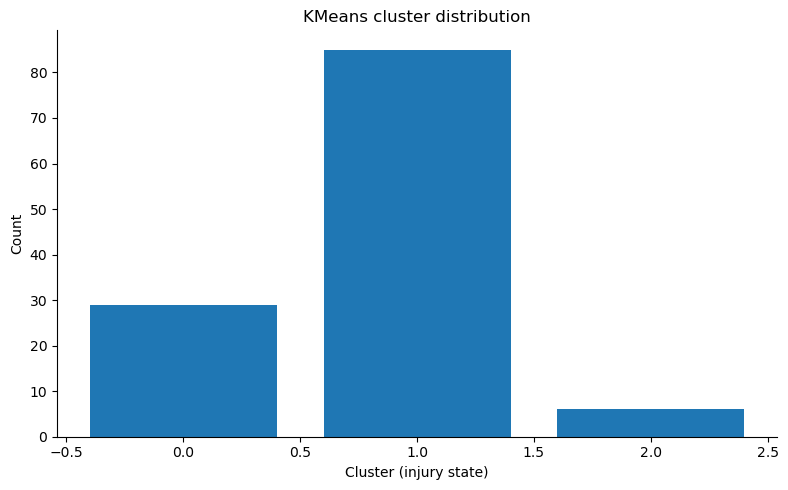

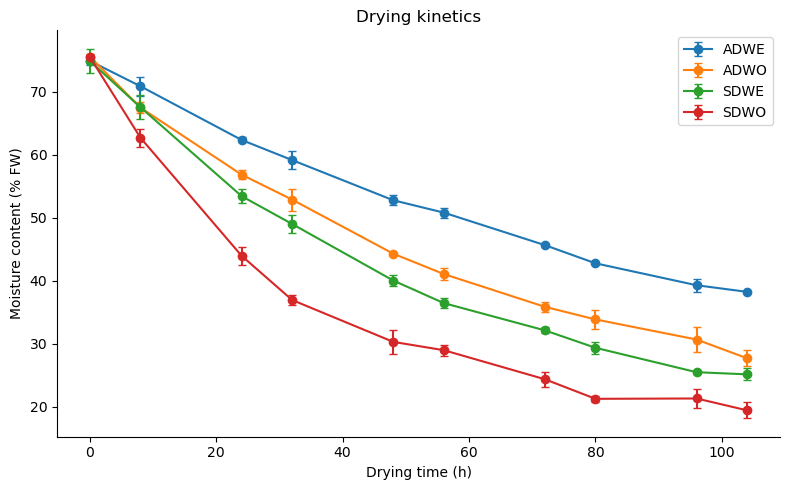

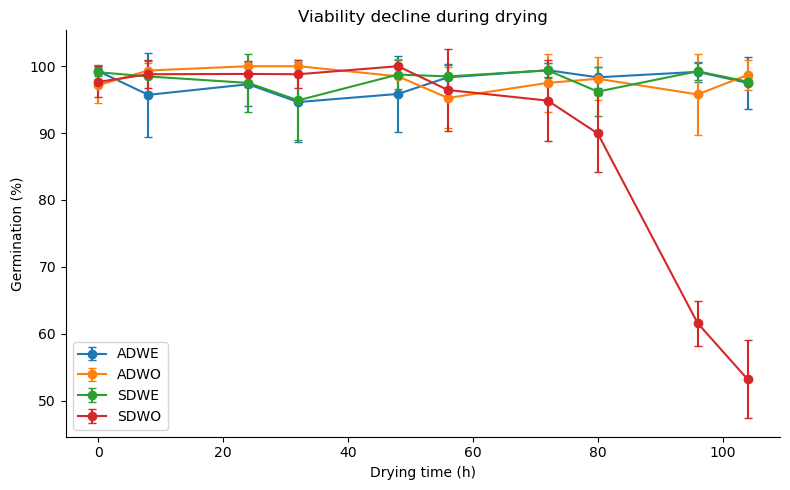

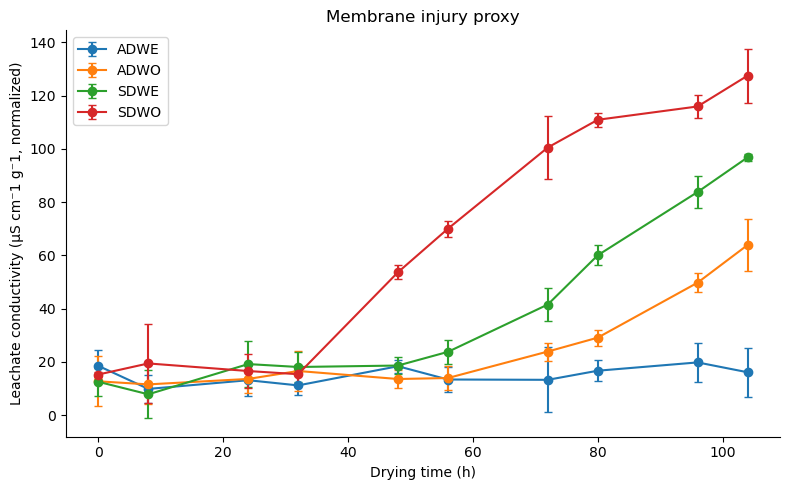

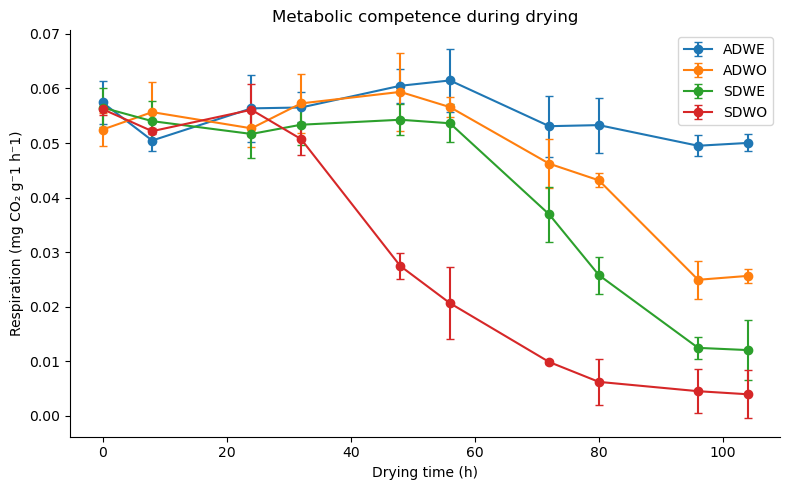

Saved:
- sim_outputs/mango_recalcitrant_drying_simulated.csv
- sim_outputs/cmc_logistic_fits.csv
- sim_outputs/time_to_threshold_metrics.csv


In [1]:
# 0) Imports and settings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, Tuple

from scipy.optimize import curve_fit
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import statsmodels.api as sm
import statsmodels.formula.api as smf

np.random.seed(42)

# Matplotlib defaults (journal-like, without forcing colors)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# 1) Experimental design
# Treatments:
# - ADWE: air drying with endocarp
# - ADWO: air drying without endocarp
# - SDWE: sun drying with endocarp
# - SDWO: sun drying without endocar
# Time points: mimic a 0–104 h drying series.
# Replicates: n=3 biological replicates per treatment x timepoint.

TREATMENTS = ["ADWE", "ADWO", "SDWE", "SDWO"]
TIME_H = np.array([0, 8, 24, 32, 48, 56, 72, 80, 96, 104], dtype=float)
N_REP = 3


# 2) Simulation model
# We simulate these variables per seed batch replicate:
# - moisture_pct: percent moisture content (FW basis)
# - germination_pct: percent germination (0–100)
# - conductivity_uS: leachate conductivity (higher = more membrane injury)
# - respiration_mgCO2_g_h: metabolic competence proxy (declines with injury; may show transient peak)

# Key biological constraints encoded:
# - Faster drying in sun vs air, and without endocarp vs with endocarp (desiccation-avoidance by endocarp).
# - Germination shows a threshold-like collapse near a critical moisture content (CMC).
# - Conductivity rises sharply as moisture drops (membrane failure).
# - Respiration declines overall; mild stress can show a transient mid-drying bump (consistent with stress metabolism).


@dataclass
class SimParams:
    mc0: float               # initial moisture (% FW)
    k_dry: float             # drying rate constant (1/h)
    mc_floor: float          # asymptotic moisture floor (% FW)
    cmc: float               # critical moisture content for viability collapse (% FW)
    germ_slope: float        # steepness of germination vs MC
    cond_base: float         # baseline conductivity (µS cm−1 g−1, normalized)
    cond_amp: float          # amplitude for conductivity increase
    cond_mid: float          # midpoint moisture (%) for conductivity rise
    cond_steep: float        # steepness for conductivity rise
    resp0: float             # initial respiration (mg CO2 g−1 h−1)
    resp_drop_mid: float     # midpoint moisture for respiration drop
    resp_drop_steep: float   # steepness for respiration drop
    resp_bump_amp: float     # transient bump amplitude
    resp_bump_t: float       # bump time center (h)
    resp_bump_w: float       # bump width (h)

def moisture_curve(t, mc0, mc_floor, k):
    # simple exponential decay to floor
    return mc_floor + (mc0 - mc_floor) * np.exp(-k * t)

def logistic(x, x0, k):
    return 1.0 / (1.0 + np.exp(-k * (x - x0)))

def simulate_one(treatment: str, t: float, rep: int, p: SimParams, noise: Dict[str, float]) -> Dict:
    # Moisture
    mc = moisture_curve(t, p.mc0, p.mc_floor, p.k_dry)
    mc_obs = mc + np.random.normal(0, noise["mc"])

    # Germination: high above CMC, collapses below
    # Use logistic centered at CMC with negative slope (higher MC => higher germ)
    germ = 100.0 * logistic(mc, p.cmc, p.germ_slope)
    germ_obs = np.clip(germ + np.random.normal(0, noise["germ"]), 0, 100)

    # Conductivity: rises as MC falls, logistic centered at cond_mid, inverted on MC
    cond = p.cond_base + p.cond_amp * (1.0 - logistic(mc, p.cond_mid, p.cond_steep))
    cond_obs = max(0.0, cond + np.random.normal(0, noise["cond"]))

    # Respiration: declines as MC falls, plus optional transient bump in time (stress response)
    resp = p.resp0 * logistic(mc, p.resp_drop_mid, p.resp_drop_steep)
    bump = p.resp_bump_amp * np.exp(-0.5 * ((t - p.resp_bump_t) / p.resp_bump_w) ** 2)
    resp_obs = max(0.0, resp + bump + np.random.normal(0, noise["resp"]))

    return dict(
        treatment=treatment,
        drying=("SD" if treatment.startswith("SD") else "AD"),
        endocarp=("WE" if treatment.endswith("WE") else "WO"),
        time_h=t,
        rep=rep,
        moisture_pct=mc_obs,
        germination_pct=germ_obs,
        conductivity_uS=cond_obs,
        respiration_mgCO2_g_h=resp_obs,
    )

# Parameterization (benchmarked ranges)
# - Initial moisture is set high (≈70–80% FW), consistent with mango seed high hydration and recalcitrance (Corbineau et al., 1986)  [oai_citation:5‡PubMed](https://pubmed.ncbi.nlm.nih.gov/14975891/?utm_source=chatgpt.com)
#   and mango desiccation/storage reports of ~69–75% MC at shedding (abstract snippet).  [oai_citation:6‡jipb.net](https://www.jipb.net/EN/abstract/abstract23528.shtml?utm_source=chatgpt.com)
# - CMC is set near ~20% FW for collapse, consistent with your experimental narrative and with recalcitrant-seed critical hydration concepts (Walters et al., 2001)  [oai_citation:7‡Cambridge University Press & Assessment](https://www.cambridge.org/core/services/aop-cambridge-core/content/view/S0960258501000137)
#   and drying-rate dependence in recalcitrant axes (Liang & Sun, 2000).  [oai_citation:8‡PubMed](https://pubmed.ncbi.nlm.nih.gov/11113169/)
# - Electrolyte leakage magnitudes: we use a normalized µS scale; baseline tens of µS and late drying up to ~100+,
#   consistent with recalcitrant leakage rising strongly with moisture loss (Fuchs et al., 2023; note mS g−1 DW values).  [oai_citation:9‡PMC](https://pmc.ncbi.nlm.nih.gov/articles/PMC10335849/)

BASE = dict(
    mc0=75.0,
    mc_floor=18.0,
    cmc=20.0,
    germ_slope=0.9,          # higher = sharper threshold
    cond_base=15.0,
    cond_amp=110.0,
    cond_mid=28.0,
    cond_steep=0.35,
    resp0=0.055,             # ~0.05 mg CO2 g−1 h−1 scale used in your manuscript narrative
    resp_drop_mid=30.0,
    resp_drop_steep=0.25,
    resp_bump_amp=0.0,
    resp_bump_t=56.0,
    resp_bump_w=10.0,
)

# Treatment-specific modifiers (drying rate & stress bump)
PARAMS: Dict[str, SimParams] = {
    "ADWE": SimParams(**{**BASE, "k_dry": 0.010, "resp_bump_amp": 0.005}),
    "ADWO": SimParams(**{**BASE, "k_dry": 0.016, "resp_bump_amp": 0.003}),
    "SDWE": SimParams(**{**BASE, "k_dry": 0.020, "resp_bump_amp": 0.006}),
    "SDWO": SimParams(**{**BASE, "k_dry": 0.032, "resp_bump_amp": 0.002}),
}

NOISE = dict(mc=1.2, germ=6.0, cond=6.0, resp=0.004)


# 3) Generate the simulated dataset

rows = []
for trt in TREATMENTS:
    p = PARAMS[trt]
    for t in TIME_H:
        for rep in range(1, N_REP + 1):
            rows.append(simulate_one(trt, t, rep, p, NOISE))

df = pd.DataFrame(rows)

# Derived fields
df["viable"] = (df["germination_pct"] >= 50).astype(int)   # operational threshold for "viable batch"
df.head()


# 4) Quick QC plots (raw trajectories)

def plot_timecourse(y, ylabel):
    for trt in TREATMENTS:
        sub = df[df["treatment"] == trt].groupby("time_h")[y].agg(["mean", "std"]).reset_index()
        plt.errorbar(sub["time_h"], sub["mean"], yerr=sub["std"], marker="o", capsize=3, label=trt)
    plt.xlabel("Drying time (h)")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_timecourse("moisture_pct", "Moisture content (% FW)")
plot_timecourse("germination_pct", "Germination (%)")
plot_timecourse("conductivity_uS", "Leachate conductivity (µS cm⁻1 g⁻1, normalized)")
plot_timecourse("respiration_mgCO2_g_h", "Respiration (mg CO₂ g⁻1 h⁻1)")


# 5) Estimate "critical moisture content" (CMC) from germination vs moisture using logistic fits
# We fit: Germination = 100 * sigmoid(MC; x0=CMC, slope)
# Then compute CMC estimate (x0) and uncertainty.


def germ_model(mc, x0, k):
    return 100.0 * logistic(mc, x0, k)

cmc_fits = []
for trt in TREATMENTS:
    sub = df[df["treatment"] == trt].copy()
    x = sub["moisture_pct"].values
    y = sub["germination_pct"].values
    # initial guesses near expected
    p0 = [20.0, 0.7]
    popt, pcov = curve_fit(germ_model, x, y, p0=p0, bounds=([5, 0.01], [60, 10]))
    x0, k = popt
    se = np.sqrt(np.diag(pcov))
    cmc_fits.append({"treatment": trt, "CMC_est": x0, "slope_est": k, "CMC_se": se[0], "slope_se": se[1]})

cmc_df = pd.DataFrame(cmc_fits)
cmc_df


# Visualize fit per treatment
mc_grid = np.linspace(df["moisture_pct"].min(), df["moisture_pct"].max(), 200)

for trt in TREATMENTS:
    sub = df[df["treatment"] == trt]
    fit = cmc_df[cmc_df["treatment"] == trt].iloc[0]
    plt.scatter(sub["moisture_pct"], sub["germination_pct"], alpha=0.6, label=f"{trt} data")
    plt.plot(mc_grid, germ_model(mc_grid, fit["CMC_est"], fit["slope_est"]), label=f"{trt} fit")
    plt.axvline(fit["CMC_est"], linestyle="--")
    plt.xlabel("Moisture content (% FW)")
    plt.ylabel("Germination (%)")
    plt.title(f"Germination vs moisture, {trt}, CMC≈{fit['CMC_est']:.2f}%")
    plt.legend()
    plt.tight_layout()
    plt.show()


# 6) Time-to-50% germination (T50) and time-to-zero (operational)
# T50 is often more robust than final germination alone when comparing drying regimes.

def t_at_threshold(trt: str, threshold: float) -> float:
    sub = df[df["treatment"] == trt].groupby("time_h")["germination_pct"].mean().reset_index()
    # interpolate time when mean crosses threshold
    t = sub["time_h"].values
    g = sub["germination_pct"].values
    # find first index where g <= threshold
    idx = np.where(g <= threshold)[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    if i == 0:
        return t[0]
    # linear interpolation between i-1 and i
    t1, t2 = t[i-1], t[i]
    g1, g2 = g[i-1], g[i]
    if g2 == g1:
        return t2
    return t1 + (threshold - g1) * (t2 - t1) / (g2 - g1)

t_metrics = []
for trt in TREATMENTS:
    t_metrics.append({
        "treatment": trt,
        "T50_h": t_at_threshold(trt, 50.0),
        "T10_h": t_at_threshold(trt, 10.0),
    })
t_metrics_df = pd.DataFrame(t_metrics)
t_metrics_df


# Bar plot
plt.bar(t_metrics_df["treatment"], t_metrics_df["T50_h"])
plt.xlabel("Treatment")
plt.ylabel("Time to 50% germination (h)")
plt.title("Drying tolerance comparison (T50)")
plt.tight_layout()
plt.show()


# 7) Mechanistic relationships: moisture ↔ conductivity ↔ respiration ↔ germination
# We examine correlations per treatment and globally.

def corr_report(sub: pd.DataFrame, label: str):
    vars_ = ["moisture_pct", "conductivity_uS", "respiration_mgCO2_g_h", "germination_pct"]
    C = pd.DataFrame(index=vars_, columns=vars_, dtype=float)
    P = pd.DataFrame(index=vars_, columns=vars_, dtype=float)
    for i, a in enumerate(vars_):
        for j, b in enumerate(vars_):
            r, p = spearmanr(sub[a], sub[b])
            C.loc[a, b] = r
            P.loc[a, b] = p
    print(f"\n=== Spearman correlations: {label} ===")
    display(C.round(3))
    return C, P

# If running in plain python, replace display(...) with print(...)
try:
    from IPython.display import display
except Exception:
    display = print

C_all, P_all = corr_report(df, "All data")

for trt in TREATMENTS:
    corr_report(df[df["treatment"] == trt], trt)


# Heatmap-like correlation visualization using imshow (matplotlib only, no seaborn)

corr = C_all.values
labels = C_all.index.tolist()

plt.imshow(corr, vmin=-1, vmax=1)
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
plt.colorbar(label="Spearman ρ")
plt.title("Correlation structure (all data)")
plt.tight_layout()
plt.show()


# 8) Statistical modeling: effects of drying mode and endocarp, controlling for time
# We fit OLS models with categorical factors.
# For repeated measures, mixed models can be used, but here we keep it broadly portable.

df["drying"] = df["drying"].astype("category")
df["endocarp"] = df["endocarp"].astype("category")
df["treatment"] = df["treatment"].astype("category")

# Germination model
m_germ = smf.ols("germination_pct ~ time_h + drying * endocarp", data=df).fit()
print(m_germ.summary())

# Conductivity model
m_cond = smf.ols("conductivity_uS ~ time_h + drying * endocarp", data=df).fit()
print(m_cond.summary())

# Respiration model
m_resp = smf.ols("respiration_mgCO2_g_h ~ time_h + drying * endocarp", data=df).fit()
print(m_resp.summary())


# 9) Multivariate patterning: PCA and clustering
# Use standardized features to see how samples organize by injury state and treatment.

features = ["moisture_pct", "conductivity_uS", "respiration_mgCO2_g_h", "germination_pct"]
X = df[features].values
Xz = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
PC = pca.fit_transform(Xz)
df["PC1"] = PC[:, 0]
df["PC2"] = PC[:, 1]

plt.scatter(df["PC1"], df["PC2"], alpha=0.6)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA of physiological state")
plt.tight_layout()
plt.show()

# Cluster injury states (k=3 as an example: viable, stressed, dead)
km = KMeans(n_clusters=3, random_state=42, n_init=20)
df["cluster"] = km.fit_predict(Xz)

for trt in TREATMENTS:
    sub = df[df["treatment"] == trt]
    plt.scatter(sub["PC1"], sub["PC2"], alpha=0.7, label=trt)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA colored by treatment")
plt.legend()
plt.tight_layout()
plt.show()

plt.hist(df["cluster"], bins=np.arange(-0.5, 3.5, 1), rwidth=0.8)
plt.xlabel("Cluster (injury state)")
plt.ylabel("Count")
plt.title("KMeans cluster distribution")
plt.tight_layout()
plt.show()


# 10) Publication-style composite figures (panel-like workflow)
# Generate a multi-figure narrative: moisture→germination→conductivity→respiration (each as its own figure)

def summarize_for_plot(y):
    out = []
    for trt in TREATMENTS:
        sub = df[df["treatment"] == trt].groupby("time_h")[y].agg(["mean", "std"]).reset_index()
        sub["treatment"] = trt
        out.append(sub)
    return pd.concat(out, ignore_index=True)

for y, ylabel, title in [
    ("moisture_pct", "Moisture content (% FW)", "Drying kinetics"),
    ("germination_pct", "Germination (%)", "Viability decline during drying"),
    ("conductivity_uS", "Leachate conductivity (µS cm⁻1 g⁻1, normalized)", "Membrane injury proxy"),
    ("respiration_mgCO2_g_h", "Respiration (mg CO₂ g⁻1 h⁻1)", "Metabolic competence during drying"),
]:
    summ = summarize_for_plot(y)
    for trt in TREATMENTS:
        s = summ[summ["treatment"] == trt]
        plt.errorbar(s["time_h"], s["mean"], yerr=s["std"], marker="o", capsize=3, label=trt)
    plt.xlabel("Drying time (h)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# 11) Export simulated data and analysis tables

out_dir = "sim_outputs"
import os
os.makedirs(out_dir, exist_ok=True)

df.to_csv(os.path.join(out_dir, "mango_recalcitrant_drying_simulated.csv"), index=False)
cmc_df.to_csv(os.path.join(out_dir, "cmc_logistic_fits.csv"), index=False)
t_metrics_df.to_csv(os.path.join(out_dir, "time_to_threshold_metrics.csv"), index=False)

print("Saved:")
print("-", os.path.join(out_dir, "mango_recalcitrant_drying_simulated.csv"))
print("-", os.path.join(out_dir, "cmc_logistic_fits.csv"))
print("-", os.path.join(out_dir, "time_to_threshold_metrics.csv"))

